In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kernelcpd import binseg
from joblib import Parallel, delayed

In [2]:
# ---- My signal generator ----
def generate_signal(seed):
    np.random.seed(seed)
    
    N = 200
    change_point = 100
    f1 = 0.05
    f2 = 0.08
    noise_std = 0.3

    n = np.arange(N)

    f = np.zeros(N)
    f[:change_point] = f1
    f[change_point:] = f2

    y = np.cos(2 * np.pi * f * n) + np.random.normal(0, noise_std, N)
    return y.reshape(-1, 1)

In [ ]:
# ---- Wrapper for one run ----
def compute_changepoint(seed, T):
    y = generate_signal(seed)
    cp = binseg(sequence=y, n_changepoints=1, T=T, laplace_option="h1") + 1
    return cp[0]

In [4]:
# ---- Parameters ----
n_signals = 500
T_values = list(range(2, 31, 2))  # 2,4,...,30

In [5]:
# ---- Parallel computation ----
def process_one_signal(seed):
    results = []
    for T in T_values:
        cp = compute_changepoint(seed, T)
        results.append(cp)
    return results

In [6]:
all_results = Parallel(n_jobs=-1)(
    delayed(process_one_signal)(seed) for seed in range(n_signals)
)

# ---- Convert to DataFrame ----
df = pd.DataFrame(all_results, columns=[f"T_{T}" for T in T_values])

# ---- Save CSV ----
df.to_csv("results/changepoint_results.csv", index=False)

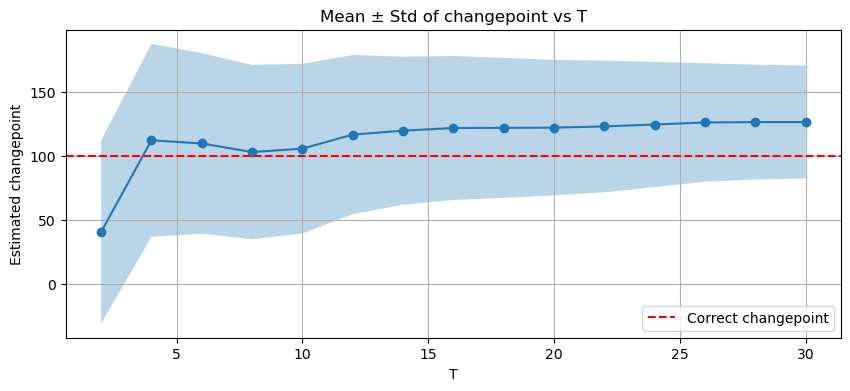

In [16]:
# ---- Compute statistics ----
df = pd.read_csv("results/changepoint_results.csv")

means = df.mean(axis=0)
stds = df.std(axis=0)

# ---- Plot ----
T_numeric = np.array(T_values)

plt.figure(figsize=(10, 4))
plt.plot(T_numeric, means.values, marker='o')
plt.fill_between(
    T_numeric,
    means.values - stds.values,
    means.values + stds.values,
    alpha=0.3
)
plt.axhline(y=100, linestyle='--', label="Correct changepoint", color="red")
plt.xlabel("T")
plt.ylabel("Estimated changepoint")
plt.title("Mean ± Std of changepoint vs T")

plt.legend()
plt.grid()
plt.show()

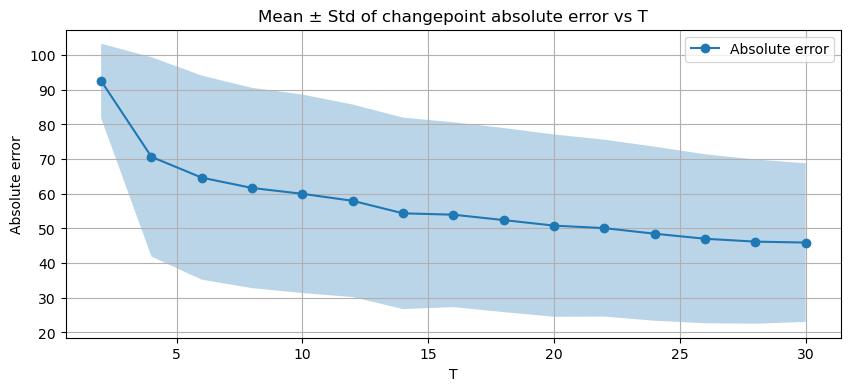

In [17]:
# ---- Compute statistics ----
errors = (df - 100).abs()

means = errors.mean(axis=0)
stds = errors.std(axis=0)

# ---- Plot ----
T_numeric = np.array(T_values)

plt.figure(figsize=(10, 4))
plt.plot(T_numeric, means.values, marker='o', label="Absolute error")

plt.fill_between(
    T_numeric,
    means.values - stds.values,
    means.values + stds.values,
    alpha=0.3
)

plt.xlabel("T")
plt.ylabel("Absolute error")
plt.title("Mean ± Std of changepoint absolute error vs T")

plt.legend()
plt.grid()
plt.show()